NOTE: Dataset was obtained from the following paper: Y. Siriwardhana et al., "Descriptor: 5G Wireless Network Intrusion Detection Dataset (5G-NIDD)," in IEEE Data Descriptions, doi: 10.1109/IEEEDATA.2025.3592888.

Dataset was downloaded here: https://etsin.fairdata.fi/dataset/9d13ef28-2ca7-44b0-9950-225359afac65 

# Incremental Learning - Elastic Weight Consolidation
Uses the MLP model as previously but applies Fisher information along with weight importance penalty to protect critical knowledge

In [ ]:
# Importing of libraries and paths
import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Paths
DATA_DIR = "../data"
MODELS_DIR = "../models"
OUT_DIR = "../outputs"
METRICS_FILE = os.path.join(DATA_DIR, "comparison_metrics.json")
LABEL_ENCODER_PATH = os.path.join(MODELS_DIR, "label_encoder.pkl")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

In [2]:
# Load datasets
X_old_df = pd.read_csv(os.path.join(DATA_DIR, "BTS2_encoded.csv"))
y_old_df = pd.read_csv(os.path.join(DATA_DIR, "BTS2_target.csv"))

X_new_df = pd.read_csv(os.path.join(DATA_DIR, "BTS1_encoded.csv"))
y_new_df = pd.read_csv(os.path.join(DATA_DIR, "BTS1_target.csv"))

# Flatten labels
y_old = y_old_df.iloc[:,0].values
y_new = y_new_df.iloc[:,0].values

X_old = X_old_df.values.astype(np.float32)
X_new = X_new_df.values.astype(np.float32)

# Label encoding
if os.path.exists(LABEL_ENCODER_PATH):
    le = joblib.load(LABEL_ENCODER_PATH)
else:
    le = LabelEncoder()
    le.fit(np.concatenate([y_old, y_new]))
    joblib.dump(le, LABEL_ENCODER_PATH)

y_old_enc = le.transform(y_old).astype(np.int64)
y_new_enc = le.transform(y_new).astype(np.int64)

num_classes = len(le.classes_)

# Train/test split on old task (BTS2)
X_old_train, X_old_test, y_old_train, y_old_test = train_test_split(
    X_old, y_old_enc, test_size=0.2, stratify=y_old_enc, random_state=42
)

print("Shapes:")
print("X_old_train:", X_old_train.shape, "X_old_test:", X_old_test.shape)
print("X_new:", X_new.shape, "y_new:", y_new_enc.shape)


Shapes:
X_old_train: (582652, 112) X_old_test: (145664, 112)
X_new: (487574, 112) y_new: (487574,)


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_size=128, output_dim=None, dropout=0.2):
        super().__init__()
        if output_dim is None:
            raise ValueError("output_dim must be provided")
        self.fc1 = nn.Linear(input_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size//2)
        self.fc_out = nn.Linear(hidden_size//2, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        return self.fc_out(x)

def predict_proba_and_pred(model, X_np):
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X_np, dtype=torch.float32, device=device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)
    return probs, preds

def evaluate_acc(model, X_np, y_np):
    _, preds = predict_proba_and_pred(model, X_np)
    return (preds == y_np).mean()



Using device: cpu


In [4]:
def compute_fisher(model, X_tr, y_tr, batch_size=128, device='cpu'):
    model.train()
    fisher = {name: torch.zeros_like(param) for name, param in model.named_parameters()}
    theta_star = {name: param.clone() for name, param in model.named_parameters()}

    n = X_tr.shape[0]
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        xb = torch.tensor(X_tr[start:end], dtype=torch.float32, device=device)
        yb = torch.tensor(y_tr[start:end], dtype=torch.long, device=device)
        model.zero_grad()
        logits = model(xb)
        log_probs = torch.log_softmax(logits, dim=1)
        target_log_probs = torch.gather(log_probs, 1, yb.unsqueeze(1)).squeeze()
        loss = -target_log_probs.mean()
        loss.backward()
        for name, param in model.named_parameters():
            if param.grad is not None:
                fisher[name] += param.grad.data.pow(2)

    # Average over samples
    for name in fisher:
        fisher[name] /= n

    return theta_star, fisher



In [5]:
def ewc_loss(model, theta_star, fisher, lambda_ewc):
    loss = 0
    for name, param in model.named_parameters():
        if name in fisher:
            loss += (fisher[name] * (param - theta_star[name]).pow(2)).sum()
    return (lambda_ewc / 2.0) * loss


In [6]:
def train_offline(model, X, y, optimizer, epochs=20, batch_size=128):
    criterion = nn.CrossEntropyLoss()
    model.train()
    n_samples = X.shape[0]
    for epoch in range(epochs):
        perm = np.random.permutation(n_samples)
        X_shuf = X[perm]
        y_shuf = y[perm]
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            xb = torch.tensor(X_shuf[start:end], dtype=torch.float32, device=device)
            yb = torch.tensor(y_shuf[start:end], dtype=torch.long, device=device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
    return model


In [7]:
def incremental_train_ewc(model, theta_star, fisher, lambda_ewc,
                        X_new_stream, y_new_stream, batch_size=128, epochs=2, optimizer=None,
                        X_old_test_local=None, y_old_test_local=None, X_new_val=None, y_new_val=None, eval_interval=50):
    model.train()
    n_samples = X_new_stream.shape[0]
    acc_old_batches, acc_new_batches, batch_idx = [], [], []
    counter = 0
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        perm = np.random.permutation(n_samples)
        X_stream = X_new_stream[perm]
        y_stream = y_new_stream[perm]
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            xb = torch.tensor(X_stream[start:end], dtype=torch.float32, device=device)
            yb = torch.tensor(y_stream[start:end], dtype=torch.long, device=device)

            optimizer.zero_grad()
            logits = model(xb)
            ce_loss = criterion(logits, yb)
            ewc_reg_loss = ewc_loss(model, theta_star, fisher, lambda_ewc)
            loss = ce_loss + ewc_reg_loss
            loss.backward()
            optimizer.step()

            counter += 1
            if counter % eval_interval == 0 or counter == 1:
                # evaluate on held-out test/val sets
                acc_old_now = evaluate_acc(model, X_old_test_local, y_old_test_local)
                acc_new_now = evaluate_acc(model, X_new_val, y_new_val)
                acc_old_batches.append(acc_old_now)
                acc_new_batches.append(acc_new_now)
                batch_idx.append(counter)
                print(f"[EWC] batch {counter} | BTS2_test: {acc_old_now:.4f} | BTS1_val: {acc_new_now:.4f}")

    return acc_old_batches, acc_new_batches, batch_idx



In [8]:
lambdas_to_run = [100, 1000, 5000]
ewc_results = {}

print("=== EWC Phase 1: Train Base Model on BTS2 ===")
base_model = MLP(X_old.shape[1], hidden_size=16, output_dim=num_classes).to(device)
optimizer_base = optim.Adam(base_model.parameters(), lr=1e-3)

# Train offline
base_model = train_offline(base_model, X_old_train, y_old_train, optimizer_base, epochs=20)

# Compute Fisher
theta_star, fisher = compute_fisher(base_model, X_old_train, y_old_train, batch_size=128, device=device)
print("Fisher and Theta_star computed.")

acc_old_initial = evaluate_acc(base_model, X_old_test, y_old_test)
acc_new_initial = evaluate_acc(base_model, X_new, y_new_enc)
print(f"Initial BTS2_test: {acc_old_initial:.4f}, BTS1: {acc_new_initial:.4f}")

HIGH_LR = 5e-2 # Use the aggressive LR that worked for Naive

for lambda_ewc in lambdas_to_run:
    print(f"\n=== EWC with lambda={lambda_ewc} ===")
    student_model = MLP(X_old.shape[1], hidden_size=16, output_dim=num_classes).to(device)
    student_model.load_state_dict(base_model.state_dict())
    optimizer_student = optim.Adam(student_model.parameters(), lr=HIGH_LR)

    acc_old_batches, acc_new_batches, batch_idx = incremental_train_ewc(
        student_model, theta_star, fisher, lambda_ewc, X_new, y_new_enc,
        batch_size=128, epochs=5, optimizer=optimizer_student, # Reduced epochs from 20 to 5
        X_old_test_local=X_old_test, y_old_test_local=y_old_test, 
        X_new_val=X_new, y_new_val=y_new_enc, eval_interval=50 # Pass evaluation sets
    )

    acc_old_final = acc_old_batches[-1] if len(acc_old_batches) > 0 else evaluate_acc(student_model, X_old_test, y_old_test)
    acc_new_final = acc_new_batches[-1] if len(acc_new_batches) > 0 else evaluate_acc(student_model, X_new, y_new_enc)
    forgetting_rate = acc_old_initial - acc_old_final
    
    # Calculate AUROC and F1 on combined (old_test + new)
    X_comb = np.vstack([X_old_test, X_new])
    y_comb = np.concatenate([y_old_test, y_new_enc])
    probs_comb, preds_comb = predict_proba_and_pred(student_model, X_comb)
    try:
        if num_classes == 2:
            auroc = roc_auc_score(y_comb, probs_comb[:,1])
        else:
            auroc = roc_auc_score(y_comb, probs_comb, multi_class='ovr', average='macro')
    except Exception as e:
        print("AUROC calc failed:", e)
        auroc = float("nan")
    f1 = f1_score(y_comb, preds_comb, average='weighted')
    

    ewc_results[lambda_ewc] = {
        "acc_old_initial": acc_old_initial,
        "acc_new_initial": acc_new_initial,
        "acc_old_final": acc_old_final,
        "acc_new_final": acc_new_final,
        "acc_old_batches": acc_old_batches,
        "acc_new_batches": acc_new_batches,
        "batch_idx": batch_idx,
        "AUROC": float(np.nan if np.isnan(auroc) else round(auroc,4)),
        "F1": float(round(f1,4)),
        "Forgetting_Rate": float(round(forgetting_rate,4))
    }
    
    # Save student model for this lambda
    model_path = os.path.join(MODELS_DIR, f"mlp_ewc_lambda_{lambda_ewc}.pth")
    torch.save(student_model.state_dict(), model_path)
    print(f"Saved EWC student model to {model_path}")
    
    # Set 'res' variable for plotting/saving section
    res = ewc_results[lambda_ewc] # <--- Ensure this line is present and runs AFTER saving above


=== EWC Phase 1: Train Base Model on BTS2 ===
Fisher and Theta_star computed.
Initial BTS2_test: 1.0000, BTS1: 1.0000

=== EWC with lambda=100 ===
[EWC] batch 1 | BTS2_test: 1.0000 | BTS1_val: 1.0000
[EWC] batch 50 | BTS2_test: 1.0000 | BTS1_val: 1.0000
[EWC] batch 100 | BTS2_test: 1.0000 | BTS1_val: 0.9996
[EWC] batch 150 | BTS2_test: 0.9982 | BTS1_val: 0.9982
[EWC] batch 200 | BTS2_test: 0.9993 | BTS1_val: 0.9993
[EWC] batch 250 | BTS2_test: 0.9995 | BTS1_val: 0.9992
[EWC] batch 300 | BTS2_test: 0.9995 | BTS1_val: 0.9992
[EWC] batch 350 | BTS2_test: 0.9995 | BTS1_val: 0.9992
[EWC] batch 400 | BTS2_test: 0.9991 | BTS1_val: 0.9989
[EWC] batch 450 | BTS2_test: 0.9782 | BTS1_val: 0.9997
[EWC] batch 500 | BTS2_test: 0.9998 | BTS1_val: 0.9993
[EWC] batch 550 | BTS2_test: 0.9998 | BTS1_val: 0.9995
[EWC] batch 600 | BTS2_test: 0.9998 | BTS1_val: 0.9995
[EWC] batch 650 | BTS2_test: 0.9998 | BTS1_val: 0.9995
[EWC] batch 700 | BTS2_test: 0.9998 | BTS1_val: 0.9995
[EWC] batch 750 | BTS2_test: 0.

Saved batch CSV: ../outputs/ewc_lambda_5000_batch_accuracies.csv


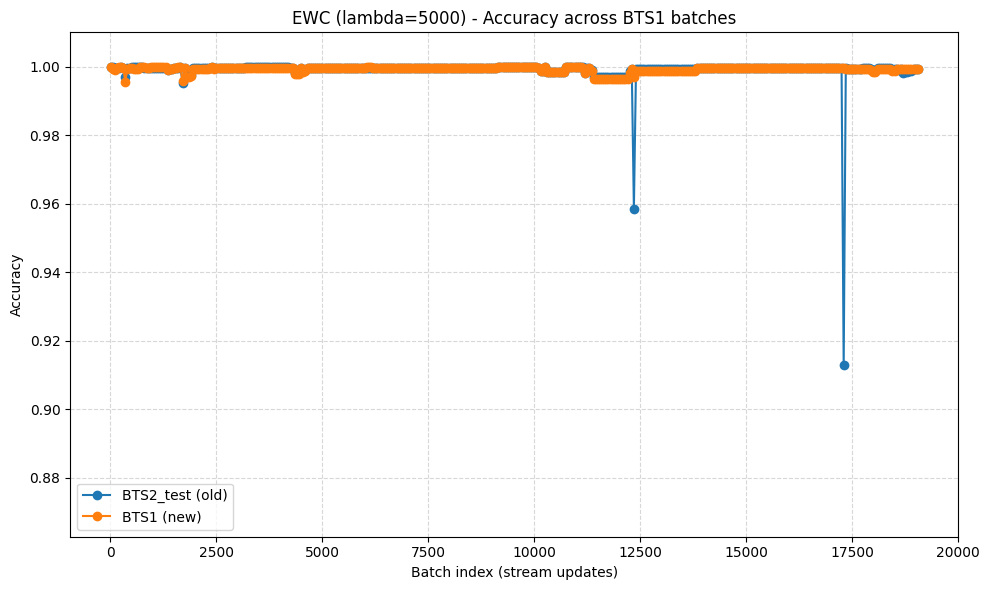

Saved forgetting curve: ../outputs/ewc_lambda_5000_forgetting_curve.png


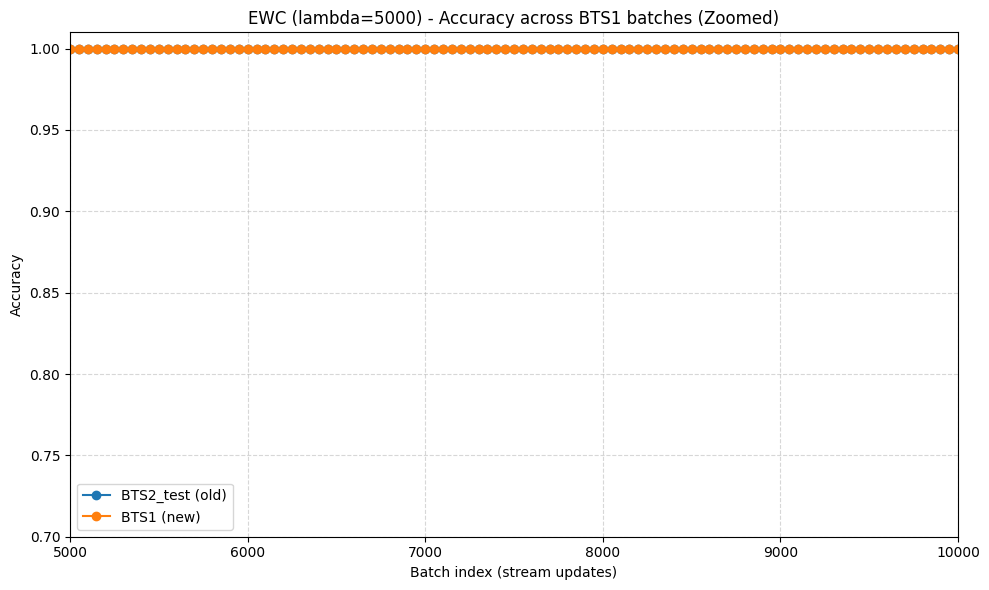

Saved zoomed forgetting curve: ../outputs/ewc_lambda_5000_forgetting_curve_zoom.png


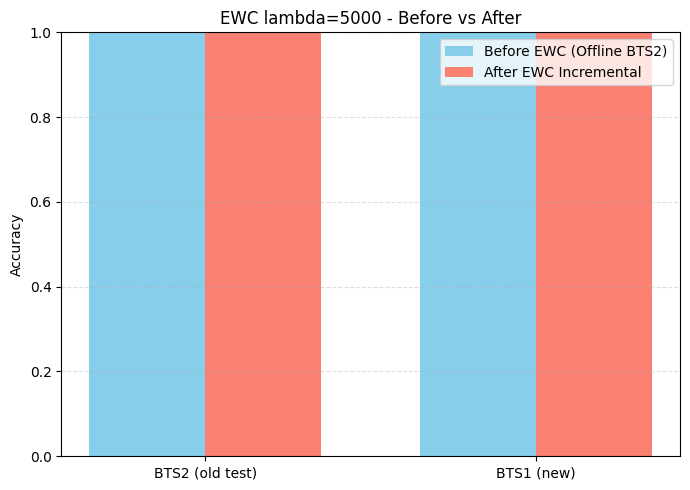

Saved before/after bar: ../outputs/ewc_lambda_5000_before_after.png
Saved metrics for EWC_lambda_5000 to ../data/comparison_metrics.json.


In [9]:
res = ewc_results[lambda_ewc] # Use the complete results dictionary

    # 1. Save Batch Accuracies CSV
df_acc = pd.DataFrame({
    "batch_idx": res["batch_idx"],
    "acc_bts2_test": res["acc_old_batches"],
    "acc_bts1": res["acc_new_batches"]
})
csv_path = os.path.join(OUT_DIR, f"ewc_lambda_{lambda_ewc}_batch_accuracies.csv")
df_acc.to_csv(csv_path, index=False)
print("Saved batch CSV:", csv_path)

# 2. Plot Forgetting Curve
plt.figure(figsize=(10,6))
plt.plot(res["batch_idx"], res["acc_old_batches"], '-o', label='BTS2_test (old)')
plt.plot(res["batch_idx"], res["acc_new_batches"], '-o', label='BTS1 (new)')
plt.xlabel("Batch index (stream updates)")
plt.ylabel("Accuracy")
plt.title(f"EWC (lambda={lambda_ewc}) - Accuracy across BTS1 batches")

min_acc_overall = min(min(res["acc_old_batches"]), min(res["acc_new_batches"]))
y_min_plot = max(0.0, min_acc_overall - 0.05) 
plt.ylim(y_min_plot ,1.01) 

plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
curve_path = os.path.join(OUT_DIR, f"ewc_lambda_{lambda_ewc}_forgetting_curve.png")
plt.savefig(curve_path, dpi=200)
plt.show()
print("Saved forgetting curve:", curve_path)

plt.figure(figsize=(10,6))
plt.plot(res["batch_idx"], res["acc_old_batches"], '-o', label='BTS2_test (old)')
plt.plot(res["batch_idx"], res["acc_new_batches"], '-o', label='BTS1 (new)')
plt.xlabel("Batch index (stream updates)")
plt.ylabel("Accuracy")
plt.title(f"EWC (lambda={lambda_ewc}) - Accuracy across BTS1 batches (Zoomed)")
    
# Set fixed Y-axis to clearly show the drops
plt.ylim(0.70, 1.01) 

# --- Set X-axis limits for the zoom (Adjust based on your drops, e.g., 5000 to 10000) ---
# We will use 5000 to 10000 as a safe range based on the image provided.
plt.xlim(5000, 10000) 

plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
curve_path_zoom = os.path.join(OUT_DIR, f"ewc_lambda_{lambda_ewc}_forgetting_curve_zoom.png")
plt.savefig(curve_path_zoom, dpi=200)
plt.show()
print("Saved zoomed forgetting curve:", curve_path_zoom)


# 3. Plot Before/After Bar
initial_old = res["acc_old_initial"]
initial_new = res["acc_new_initial"]
final_old = res["acc_old_final"]
final_new = res["acc_new_final"]

plt.figure(figsize=(7,5))
labels = ['BTS2 (old test)', 'BTS1 (new)']
x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, [initial_old, initial_new], width, label='Before EWC (Offline BTS2)', color='skyblue')
plt.bar(x + width/2, [final_old, final_new], width, label='After EWC Incremental', color='salmon')
plt.xticks(x, labels)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title(f"EWC lambda={lambda_ewc} - Before vs After")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
bar_path = os.path.join(OUT_DIR, f"ewc_lambda_{lambda_ewc}_before_after.png")
plt.savefig(bar_path, dpi=200)
plt.show()
print("Saved before/after bar:", bar_path)

# 4. Save/Update JSON Metrics
key_name = f"EWC_lambda_{lambda_ewc}"
try:
    with open(METRICS_FILE, 'r') as f:
        metrics_all = json.load(f)
except (FileNotFoundError, json.JSONDecodeError):
    metrics_all = {}

metrics_all[key_name] = {
    "accuracy_data": {
        "BTS2 (Old)": float(round(final_old,4)),
        "BTS1 (New)": float(round(final_new,4))
    },
    "metrics_data": {
        "AUROC": res["AUROC"],
        "F1-Score": res["F1"],
        "Forgetting Rate": res["Forgetting_Rate"]
    }
}

with open(METRICS_FILE, 'w') as f:
    json.dump(metrics_all, f, indent=4)

print(f"Saved metrics for {key_name} to {METRICS_FILE}.")

In [ ]:
# Summary of results from EWC

print("\n=== EWC Final Summary ===")
for lambda_ewc, res in ewc_results.items():
    print(f"\nLambda = {lambda_ewc}")
    print(f"  Initial (base) BTS2_test acc: {res['acc_old_initial']:.4f}")
    print(f"  Final BTS2_test acc: {res['acc_old_final']:.4f}")
    print(f"  Final BTS1 acc: {res['acc_new_final']:.4f}")
    print(f"  AUROC: {res['AUROC']}, F1: {res['F1']}, Forgetting Rate: {res['Forgetting_Rate']}")


=== EWC Final Summary ===

Lambda = 100
  Initial (base) BTS2_test acc: 1.0000
  Final BTS2_test acc: 0.9998
  Final BTS1 acc: 0.9997
  AUROC: 1.0, F1: 0.9997, Forgetting Rate: 0.0002

Lambda = 1000
  Initial (base) BTS2_test acc: 1.0000
  Final BTS2_test acc: 0.9999
  Final BTS1 acc: 0.9999
  AUROC: 0.9998, F1: 0.9999, Forgetting Rate: 0.0

Lambda = 5000
  Initial (base) BTS2_test acc: 1.0000
  Final BTS2_test acc: 0.9994
  Final BTS1 acc: 0.9994
  AUROC: 1.0, F1: 0.9994, Forgetting Rate: 0.0006
